<a href="https://colab.research.google.com/github/szabeebzaliz7-a11y/Datascience-And-Gen-AI/blob/main/Assignment_13_Generative_Adversarial_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI and GenAI Assignment

Objective:

To implement and train a simple Generative Adversarial Network (GAN) using TensorFlow
(Keras API) to generate handwritten digit images that resemble the MNIST dataset.
This mini-assignment aims to strengthen your understanding of adversarial learning and
generative modeling.

Task Description:

You are required to:

1. Build and train a GAN model using TensorFlow 2.x (Keras API) consisting of:
○ Generator Network: Takes a random noise vector (e.g., 100-dimensional) and
outputs a 28×28 grayscale image.
○ Discriminator Network: Classifies input images (real or generated) as true (1) or
fake (0).

Dataset: Use the MNIST dataset available in TensorFlow:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

2.
○ Normalize the data to the range [-1, 1] and reshape to (28, 28, 1).
3. Model Design Guidelines:
○ Generator:
■ Layers: Dense → BatchNormalization → LeakyReLU → Conv2DTranspose
→ Output (Tanh)
○ Discriminator:
■ Layers: Conv2D → LeakyReLU → Dropout → Flatten → Dense (Sigmoid)

○ Loss Function: Binary Cross-Entropy (BCE)
○ Optimizer: Adam (learning rate = 0.0002, β1 = 0.5)
○ Train for at least 20 epochs and visualize the progress.
4. Output Requirement:
○ Display a grid of generated digit images every few epochs.
○ Plot loss curves for generator and discriminator.

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Reshape, Flatten, Conv2D, Conv2DTranspose, BatchNormalization, LeakyReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import tensorflow.keras.layers as layers
import os
import time
from IPython.display import clear_output

In [3]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32')
x_train=(x_train-127.5)/127.5
BUFFER_SIZE=60000
BATCH_SIZE=256
train_dataset=tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

In [6]:
def make_generator_model():
    model=Sequential()
    model.add(Dense(7*7*256,use_bias=False,input_shape=(100,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Reshape((7,7,256)))
    assert model.output_shape==(None,7,7,256)

    model.add(Conv2DTranspose(128,(5,5),strides=(1,1),padding='same',use_bias=False))
    assert model.output_shape==(None,7,7,128)
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Conv2DTranspose(64,(5,5),strides=(2,2),padding='same',use_bias=False))
    assert model.output_shape==(None,14,14,64)
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Conv2DTranspose(1,(5,5),strides=(2,2),padding='same',use_bias=False,activation='tanh'))
    assert model.output_shape==(None,28,28,1)

    return model


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


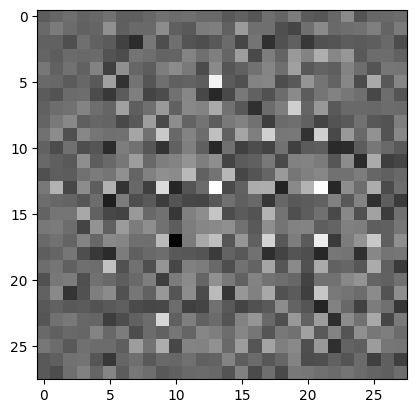

In [7]:
generator=make_generator_model()
noise=tf.random.normal([1,100])
generated_image=generator(noise,training=False)

plt.imshow(generated_image[0,:,:,0],cmap='gray')

In [8]:
def make_discriminator_model():
  model=tf.keras.Sequential()
  model.add(layers.Conv2D(64,(5,5),strides=(2,2),padding='same',input_shape=[28,28,1]))
  model.add(layers.LeakyReLU())
  model.add(layers.Dropout(0.3))

  model.add(layers.Conv2D(128,(5,5),strides=(2,2),padding='same'))
  model.add(layers.LeakyReLU())
  model.add(layers.Dropout(0.3))

  model.add(layers.Flatten())
  model.add(layers.Dense(1))

  return model

In [9]:
discriminator=make_discriminator_model()
decision=discriminator(generated_image)
print(decision)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


tf.Tensor([[-0.00039447]], shape=(1, 1), dtype=float32)


In [10]:
cross_entropy=tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [11]:
def discriminator_loss(real_output,fake_output):
  real_loss=cross_entropy(tf.ones_like(real_output),real_output)
  fake_loss=cross_entropy(tf.zeros_like(fake_output),fake_output)
  total_loss=real_loss+fake_loss
  return total_loss

In [12]:
def generator_loss(fake_output):
  return cross_entropy(tf.ones_like(fake_output),fake_output)


In [13]:
generator_optimizer=tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer=tf.keras.optimizers.Adam(1e-4)

In [14]:
checkpoint_dir='./training_checkpoints'
checkpoint_prefix=os.path.join(checkpoint_dir,'ckpt')
checkpoint=tf.train.Checkpoint(generator_optimizer=generator_optimizer,discriminator_optimizer=discriminator_optimizer,generator=generator,discriminator=discriminator)

In [15]:
EPOCHS=50
noise_dim=100
num_examples_to_generate=16
seed=tf.random.normal([num_examples_to_generate,noise_dim])

In [16]:

gen_loss_history=[]
disc_loss_history=[]
@tf.function
def train_step(images):
  noise=tf.random.normal([BATCH_SIZE,noise_dim])

  with tf.GradientTape() as gen_tape,tf.GradientTape() as disc_tape:
    generated_images=generator(noise,training=True)

    real_output=discriminator(images,training=True)
    fake_output=discriminator(generated_images,training=True)

    gen_loss=generator_loss(fake_output)
    disc_loss=discriminator_loss(real_output,fake_output)

    gradients_of_generator=gen_tape.gradient(gen_loss,generator.trainable_variables)
    gradients_of_discriminator=disc_tape.gradient(disc_loss,discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator,generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator,discriminator.trainable_variables))

    return gen_loss,disc_loss

In [17]:

def generate_and_save_images(model,epoch,test_input):
  predictions=model(test_input,training=False)
  fig=plt.figure(figsize=(4,4))

  for i in range(predictions.shape[0]):
    plt.subplot(4,4,i+1)
    plt.imshow(predictions[i,:,:,0]*127.5+127.5,cmap='gray')
    plt.axis('off')

  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

In [22]:
def train(dataset, epochs):
    # Remove local initialization of gen_loss_history and disc_loss_history
    # They are already declared globally

    for epoch in range(epochs):
        start = time.time()

        epoch_gen_loss = []
        epoch_disc_loss = []

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            epoch_gen_loss.append(gen_loss)
            epoch_disc_loss.append(disc_loss)

        # Store average loss per epoch
        gen_loss_history.append(
            tf.reduce_mean(epoch_gen_loss).numpy()
        )
        disc_loss_history.append(
            tf.reduce_mean(epoch_disc_loss).numpy()
        )

        clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)

        if (epoch + 1) % 15 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        print(
            f"Epoch {epoch+1}, "
            f"Gen Loss: {gen_loss_history[-1]:.4f}, "
            f"Disc Loss: {disc_loss_history[-1]:.4f}, "
            f"Time: {time.time()-start:.2f}s"
        )

    clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)

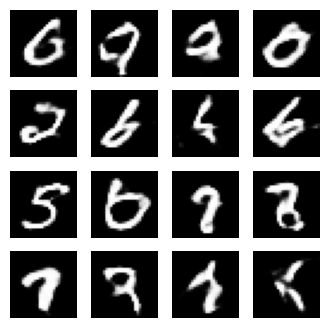

In [23]:
train(train_dataset, EPOCHS)

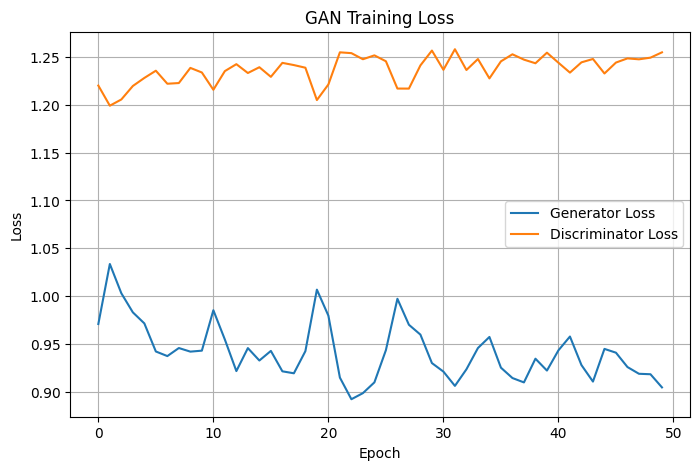

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(gen_loss_history, label='Generator Loss')
plt.plot(disc_loss_history, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Loss')
plt.legend()
plt.grid(True)
plt.show()